![aaron judge](judge_wide.jpg)

This is Aaron Judge. Judge is one of the physically largest players in Major League Baseball standing 6 feet 7 inches (2.01 m) tall and weighing 282 pounds (128 kg). He also hit one of the hardest home runs ever recorded. How do we know this? Statcast.

Statcast is a state-of-the-art tracking system that uses high-resolution cameras and radar equipment to measure the precise location and movement of baseballs and baseball players. Introduced in 2015 to all 30 major league ballparks, Statcast data is revolutionizing the game. Teams are engaging in an "arms race" of data analysis, hiring analysts left and right in an attempt to gain an edge over their competition.

In this project, you're going to wrangle, analyze, and visualize Statcast historical data to compare Mr. Judge and another (extremely large) teammate of his, Giancaro Stanton. They are similar in a lot of ways, one being that they hit a lot of home runs. Stanton and Judge led baseball in home runs in 2017, with 59 and 52, respectively. These are exceptional totals - the player in third "only" had 45 home runs.

Stanton and Judge are also different in many ways. Let's find out how they compare!

**The Data**

There are two CSV files, `judge.csv` and `stanton.csv`, both of which contain Statcast data for 2015-2017. Each row represents one pitch thrown to a batter. 

**Custom Functions**

Two functions have also been provided for you to visualize home rome zones
- `assign_x_coord`: Assigns an x-coordinate to Statcast's strike zone numbers.
- `assign_y_coord`: Assigns a y-coordinate to Statcast's strike zone numbers.

![](zone.png)

In [65]:
# Run this cell to begin
# Import the necessary packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Load Aaron Judge's Statcast data
judge = pd.read_csv('judge.csv')

# Load Giancarlo Stanton's Statcast data
stanton = pd.read_csv('stanton.csv')

# Display all columns (pandas will collapse some columns if we don't set this option)
pd.set_option('display.max_columns', None)

# Custom Functions
def assign_x_coord(row):
    """
    Assigns an x-coordinate to Statcast's strike zone numbers. Zones 11, 12, 13,
    and 14 are ignored for plotting simplicity.
    """
    # Left third of strike zone
    if row.zone in [1, 4, 7]:
        return 1
    # Middle third of strike zone
    if row.zone in [2, 5, 8]:
        return 2
    # Right third of strike zone
    if row.zone in [3, 6, 9]:
        return 3
    
def assign_y_coord(row):
    """
    Assigns a y-coordinate to Statcast's strike zone numbers. Zones 11, 12, 13,
    and 14 are ignored for plotting simplicity.
    """
    # Upper third of strike zone
    if row.zone in [1, 2, 3]:
        return 3
    # Middle third of strike zone
    if row.zone in [4, 5, 6]:
        return 2
    # Lower third of strike zone
    if row.zone in [7, 8, 9]:
        return 1
    
# Display the last five rows of the Aaron Judge file
judge.tail()

,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,spin_dir,spin_rate_deprecated,break_angle_deprecated,break_length_deprecated,zone,des,game_type,stand,p_throws,home_team,away_team,type,hit_location,bb_type,balls,strikes,game_year,pfx_x,pfx_z,plate_x,plate_z,on_3b,on_2b,on_1b,outs_when_up,inning,inning_topbot,hc_x,hc_y,tfs_deprecated,tfs_zulu_deprecated,pos2_person_id,umpire,sv_id,vx0,vy0,vz0,ax,ay,az,sz_top,sz_bot,hit_distance_sc,launch_speed,launch_angle,effective_speed,release_spin_rate,release_extension,game_pk,pos1_person_id,pos2_person_id.1,pos3_person_id,pos4_person_id,pos5_person_id,pos6_person_id,pos7_person_id,pos8_person_id,pos9_person_id,release_pos_y,estimated_ba_using_speedangle,estimated_woba_using_speedangle,woba_value,woba_denom,babip_value,iso_value,launch_speed_angle,at_bat_number,pitch_number
3431,CH,2016-08-13,85.6,-1.9659,5.9113,Aaron Judge,592450,542882,NaN,ball,NaN,NaN,NaN,NaN,14.0,NaN,R,R,R,NYY,TB,B,NaN,NaN,0,0,2016,-0.379108,0.370567,0.739,1.442,NaN,NaN,NaN,0,5,Bot,NaN,NaN,NaN,NaN,571912.0,NaN,160813_144259,6.960,-124.371,-4.756,-2.821,23.634,-30.220,3.93,1.82,NaN,NaN,NaN,84.459,1552.0,5.683,448611,542882.0,571912.0,543543.0,523253.0,446334.0,622110.0,545338.0,595281.0,543484.0,54.8144,0.00,0.000,NaN,NaN,NaN,NaN,NaN,36,1
3432,CH,2016-08-13,87.6,-1.9318,5.9349,Aaron Judge,592450,542882,home_run,hit_into_play_score,NaN,NaN,NaN,NaN,4.0,Aaron Judge homers (1) on a fly ball to center...,R,R,R,NYY,TB,X,NaN,fly_ball,1,2,2016,-0.295608,0.320400,-0.419,3.273,NaN,NaN,NaN,2,2,Bot,130.45,14.58,NaN,NaN,571912.0,NaN,160813_135833,4.287,-127.452,-0.882,-1.972,24.694,-30.705,4.01,1.82,446.0,108.8,27.410,86.412,1947.0,5.691,448611,542882.0,571912.0,543543.0,523253.0,446334.0,622110.0,545338.0,595281.0,543484.0,54.8064,0.98,1.937,2.0,1.0,0.0,3.0,6.0,14,4
3433,CH,2016-08-13,87.2,-2.0285,5.8656,Aaron Judge,592450,542882,NaN,ball,NaN,NaN,NaN,NaN,14.0,NaN,R,R,R,NYY,TB,B,NaN,NaN,0,2,2016,-0.668575,0.198567,0.561,0.960,NaN,NaN,NaN,2,2,Bot,NaN,NaN,NaN,NaN,571912.0,NaN,160813_135815,7.491,-126.665,-5.862,-6.393,21.952,-32.121,4.01,1.82,NaN,NaN,NaN,86.368,1761.0,5.721,448611,542882.0,571912.0,543543.0,523253.0,446334.0,622110.0,545338.0,595281.0,543484.0,54.7770,0.00,0.000,NaN,NaN,NaN,NaN,NaN,14,3
3434,CU,2016-08-13,79.7,-1.7108,6.1926,Aaron Judge,592450,542882,NaN,foul,NaN,NaN,NaN,NaN,4.0,NaN,R,R,R,NYY,TB,S,NaN,NaN,0,1,2016,0.397442,-0.614133,-0.803,2.742,NaN,NaN,NaN,2,2,Bot,NaN,NaN,NaN,NaN,571912.0,NaN,160813_135752,1.254,-116.062,0.439,5.184,21.328,-39.866,4.01,1.82,9.0,55.8,-24.973,77.723,2640.0,5.022,448611,542882.0,571912.0,543543.0,523253.0,446334.0,622110.0,545338.0,595281.0,543484.0,55.4756,0.00,0.000,NaN,NaN,NaN,NaN,1.0,14,2
3435,FF,2016-08-13,93.2,-1.8476,6.0063,Aaron Judge,592450,542882,NaN,called_strike,NaN,NaN,NaN,NaN,8.0,NaN,R,R,R,NYY,TB,S,NaN,NaN,0,0,2016,-0.823050,1.623300,-0.273,2.471,NaN,NaN,NaN,2,2,Bot,NaN,NaN,NaN,NaN,571912.0,NaN,160813_135736,5.994,-135.497,-6.736,-9.360,26.782,-13.446,4.01,1.82,NaN,NaN,NaN,92.696,2271.0,6.068,448611,542882.0,571912.0,543543.0,523253.0,446334.0,622110.0,545338.0,595281.0,543484.0,54.4299,0.00,0.000,NaN,NaN,NaN,NaN,NaN,14,1


In [66]:
# Start coding here. Use as many cells as you like!
# Counting how many events Judge & Stanton had in year 2017

judge_events_2017 = (judge[judge['game_year'] == 2017]['events']).value_counts()
stanton_events_2017 = (stanton[stanton['game_year'] == 2017]['events']).value_counts()

print("Judge Event counts in 2017:\n",judge_events_2017)
print("Stanton Event counts in 2017:\n",stanton_events_2017)

Judge Event counts in 2017:
 strikeout                    207
field_out                    146
walk                         116
single                        75
home_run                      52
double                        24
grounded_into_double_play     15
force_out                     11
intent_walk                   11
hit_by_pitch                   5
sac_fly                        4
fielders_choice_out            4
field_error                    4
triple                         3
strikeout_double_play          1
Name: events, dtype: int64
Stanton Event counts in 2017:
 field_out                    239
strikeout                    161
single                        77
walk                          72
home_run                      59
double                        32
intent_walk                   13
grounded_into_double_play     13
force_out                      7
hit_by_pitch                   7
field_error                    5
sac_fly                        3
fielders_choice_out   

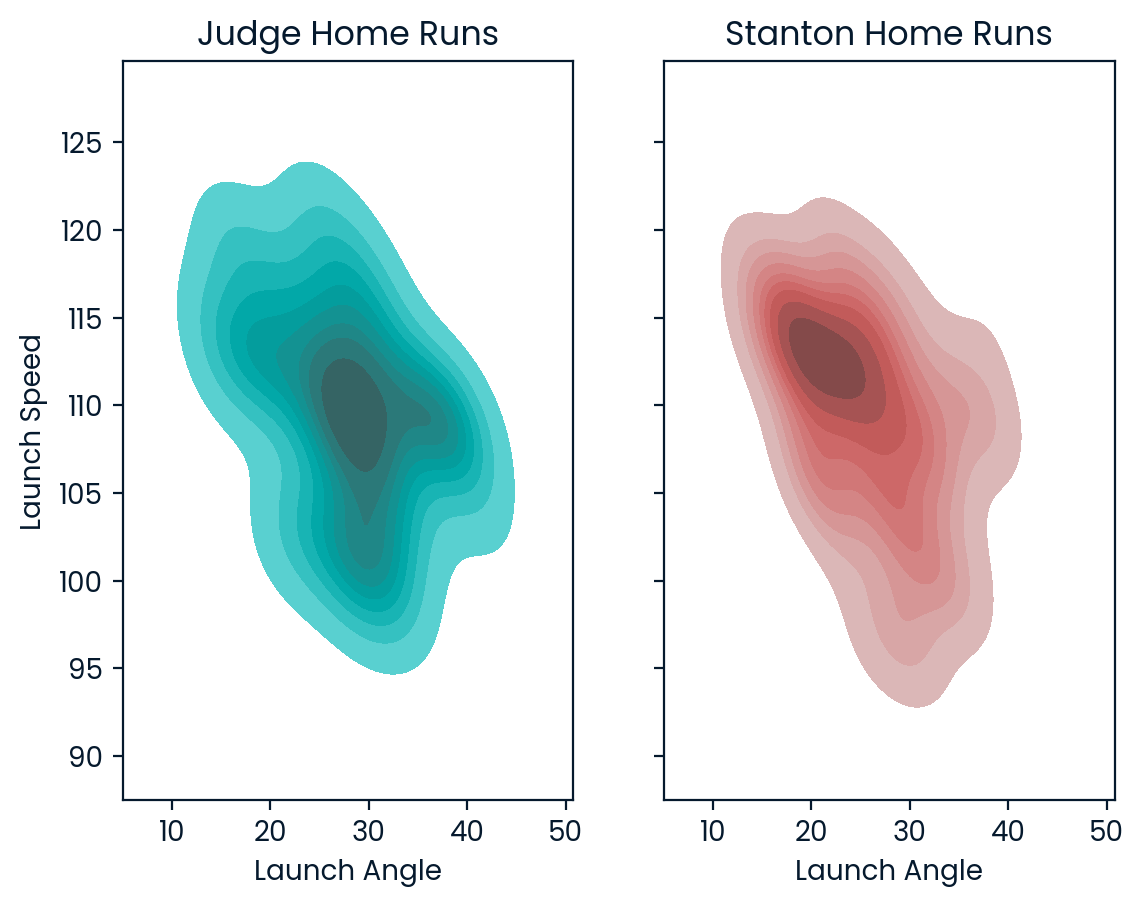

In [67]:
# Visualize the launch angle and launch speed for each player

judge_hr = judge[judge['events'] == "home_run"]
stanton_hr = stanton[stanton['events'] == 'home_run']

fig1, ax1 = plt.subplots(1,2, sharex = True, sharey = True)
sns.kdeplot(x='launch_angle', y='launch_speed', data= judge_hr, ax = ax1[0], fill=True, color='teal')
ax1[0].set_xlabel("Launch Angle")
ax1[0].set_ylabel('Launch Speed')
ax1[0].set_title('Judge Home Runs')

sns.kdeplot(x='launch_angle', y='launch_speed', data=stanton_hr, ax = ax1[1], fill=True, color='indianred')
ax1[1].set_xlabel("Launch Angle")
ax1[1].set_ylabel('Launch Speed')
ax1[1].set_title('Stanton Home Runs')

player_hr = "Stanton"

Judge's pitch velocity in home runs was faster, median = 91.69999999999999


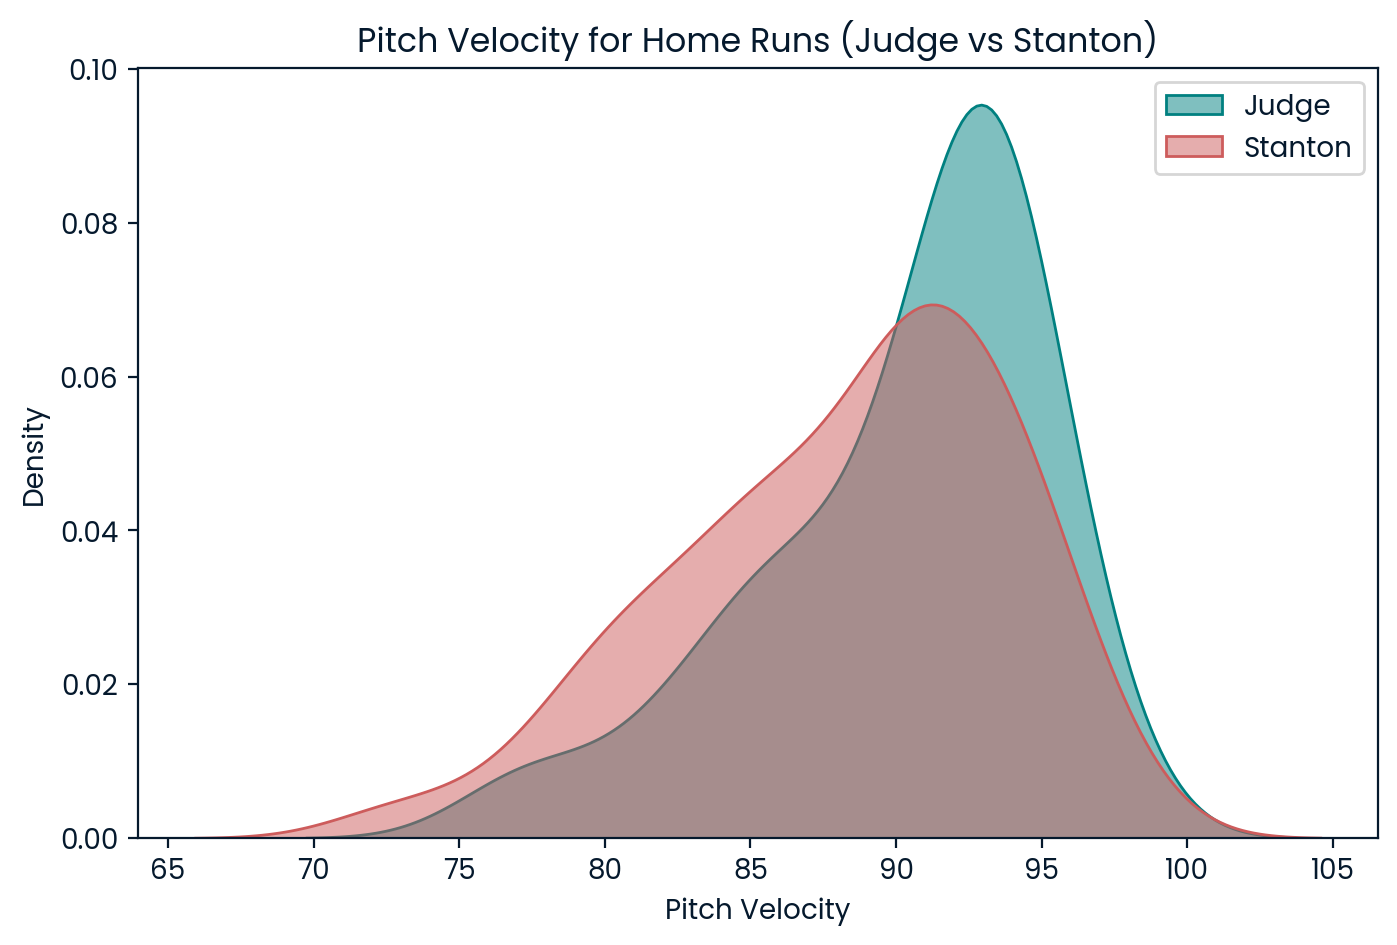

In [68]:
# Compare pitch velocity (release_speed) for both players (with explicitly calculating median)

judge_fast = judge_hr['release_speed'].median()
stanton_fast = stanton_hr['release_speed'].median()

if judge_fast > stanton_fast:
    print(f"Judge's pitch velocity in home runs was faster, median = {judge_fast}")
elif stanton_fast > judge_fast:
    print(f"Stanton's pitch velocity in home runs was faster, median = {stanton_fast}")
else:
    print(f"Both players' pitch velocity are equal. Judge: {judge_fast}, Stanton: {stanton_fast}")

plt.figure(figsize=(8,5))
sns.kdeplot(x= judge_hr['release_speed'], label = 'Judge', fill=True, color='teal', alpha=0.5)
sns.kdeplot(x=stanton_hr['release_speed'], label = 'Stanton', fill=True, color='indianred', alpha=0.5)

plt.xlabel("Pitch Velocity")
plt.title('Pitch Velocity for Home Runs (Judge vs Stanton)')
plt.legend()
plt.show()

In [69]:
# Concatenate Home run data
judge_hr['player'] = 'Judge'
stanton_hr['player'] = 'Stanton'

combined_df = pd.concat([judge_hr, stanton_hr], ignore_index = True)
print(combined_df.head())

  pitch_type   game_date  release_speed  release_pos_x  release_pos_z  \
0         FT  2017-09-30           93.1        -1.4675         5.3552   
1         FF  2017-09-28           91.4        -1.2834         6.5190   
2         CH  2017-09-25           84.3        -2.1259         6.1178   
3         FF  2017-09-25           93.0        -2.5921         5.8090   
4         SI  2017-09-24           96.5        -2.2724         6.0514   

   player_name  batter  pitcher    events          description  spin_dir  \
0  Aaron Judge  592450   573186  home_run  hit_into_play_score       NaN   
1  Aaron Judge  592450   607188  home_run  hit_into_play_score       NaN   
2  Aaron Judge  592450   502239  home_run  hit_into_play_score       NaN   
3  Aaron Judge  592450   596001  home_run  hit_into_play_score       NaN   
4  Aaron Judge  592450   572193  home_run  hit_into_play_score       NaN   

   spin_rate_deprecated  break_angle_deprecated  break_length_deprecated  \
0                   NaN     

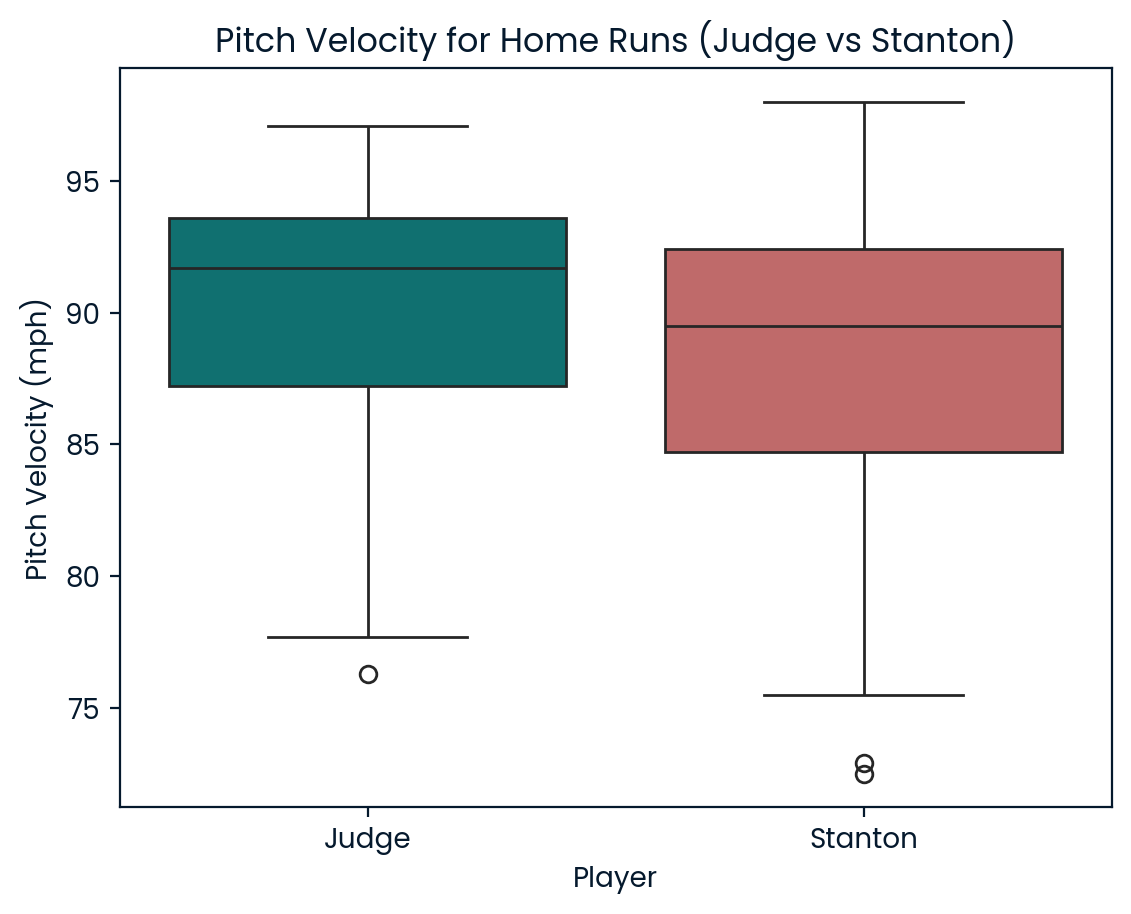

In [70]:
# Use seaborn to create a boxplot on concatenated dataframe (without explicitly calculating median)

sns.boxplot(data= combined_df, x='player', y='release_speed', palette=['teal', 'indianred'])
plt.xlabel('Player')
plt.ylabel('Pitch Velocity (mph)')
plt.title('Pitch Velocity for Home Runs (Judge vs Stanton)')
plt.show()

player_fast = "Judge"

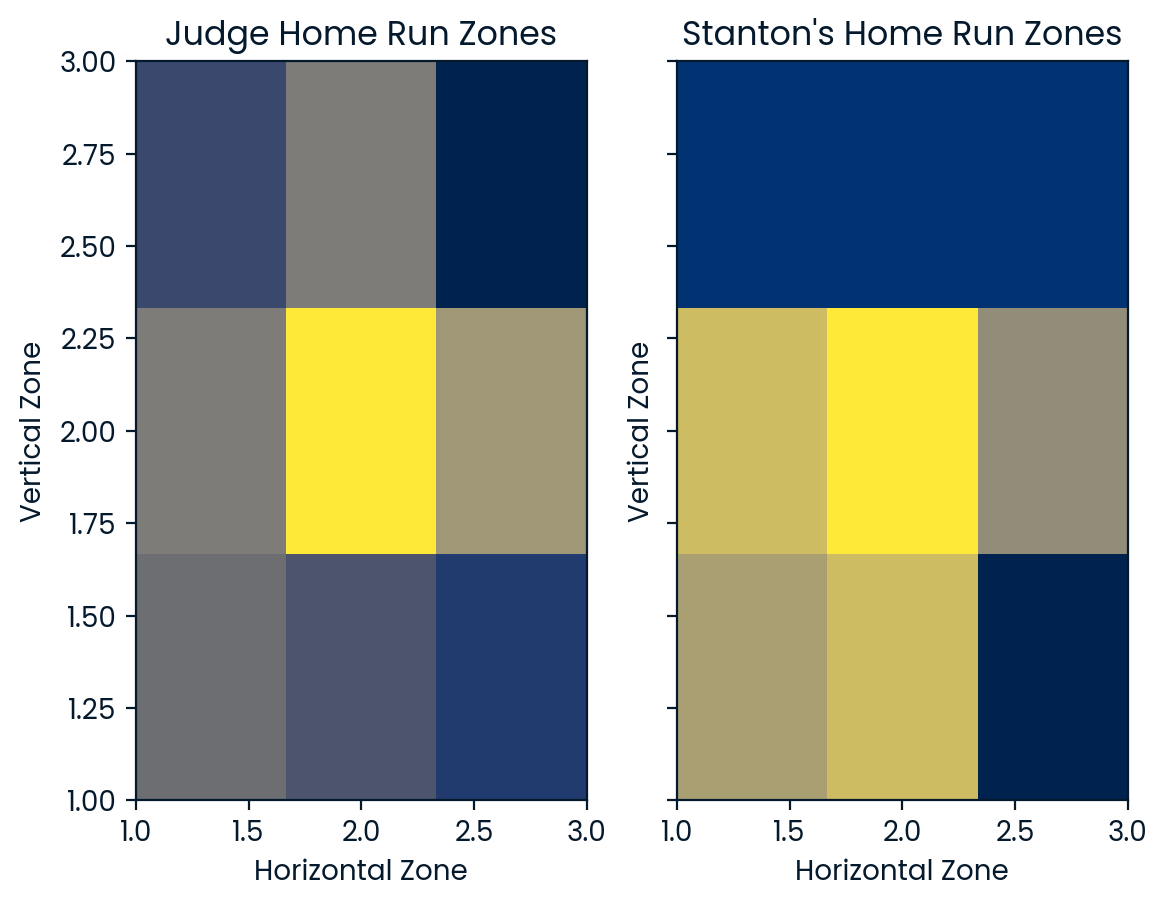

In [71]:
# Create a copy from filtered home run DataFrame
judge_strike_hr = judge_hr.copy()
stanton_strike_hr = stanton_hr.copy()

# Filter 1-9 zones based on task requirement
judge_strike_hr = judge_strike_hr.loc[judge_strike_hr['zone'] <= 9]
stanton_strike_hr = stanton_strike_hr.loc[stanton_strike_hr['zone'] <= 9]

# Using custom functions in cell 1, assign Cartesian Coordinates
judge_strike_hr['zone_x'] = judge_strike_hr.apply(assign_x_coord, axis=1)
judge_strike_hr['zone_y'] = judge_strike_hr.apply(assign_y_coord, axis=1)

stanton_strike_hr['zone_x'] = stanton_strike_hr.apply(assign_x_coord, axis=1)
stanton_strike_hr['zone_y'] = stanton_strike_hr.apply(assign_y_coord, axis=1)

# Create 2D Histogram
fig, ax = plt.subplots(1,2, sharex=True, sharey=True)

ax[0].hist2d(judge_strike_hr['zone_x'], judge_strike_hr['zone_y'], cmap='cividis', bins=(3,3))
ax[0].set_title("Judge Home Run Zones")
ax[0].set_xlabel("Horizontal Zone")
ax[0].set_ylabel("Vertical Zone")

ax[1].hist2d(stanton_strike_hr['zone_x'], stanton_strike_hr['zone_y'], cmap='cividis', bins=(3,3))
ax[1].set_title("Stanton's Home Run Zones")
ax[1].set_xlabel("Horizontal Zone")
ax[1].set_ylabel("Vertical Zone")

plt.show()